In [1]:
import sys,os
sys.path.append('../../')
os.environ["JAX_PLATFORMS"] = "cpu"
import matplotlib.pyplot as plt
import numpy as np
from utils import makefolder,depths,reduce_list_half_preserve_extremes

from geometry import * 

eps = 1E-7
rcpsize = 14
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']

from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
markers = ['o','s', 'p','h','^','*']
_linestyles = ['-','--','dotted']
plot_id = 0


/home/acevedo/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
modelA = 'deepseek'
# modelA = 'qwen7b'
modelB = modelA
languages = [
            'english',
            ]

layers_A = list(range(1,depths[modelA] + 1))
layers_B = list(range(1,depths[modelB] + 1))
layers = np.array(reduce_list_half_preserve_extremes(layers_A),dtype=float)
layers /= depths[modelB]

# layers = np.arange(1,depths[modelB] + 1) / depths[modelA]

global_centering = 0
batch_shuffle = 0
centers_var = 'syn'
n_files = 21
batch_size = 100
avg_flags = [0,1]
Nbits = 0
data_var ='syn'
zero_activations_list = [0]
center_B_flags = [0,1,-1]
center_A_flags = center_B_flags

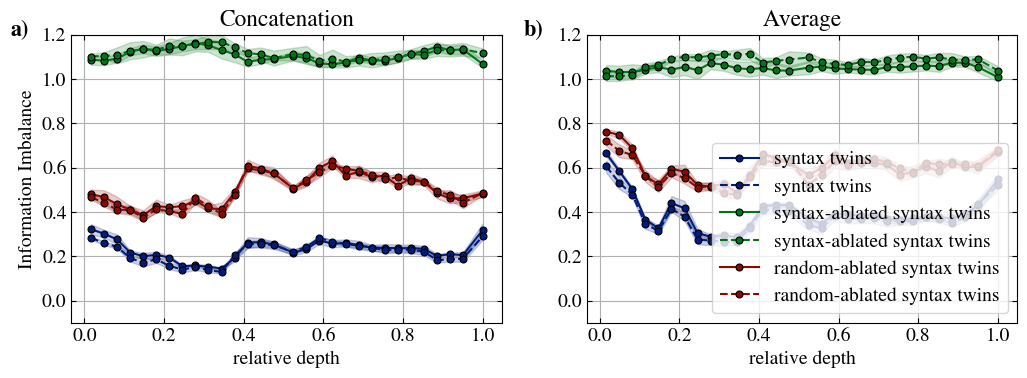

In [8]:
precision = 32
ratio_jackknife = 0.5
fig,ax = plt.subplots(1,2,figsize=(10.5,4))

min_token_length = 6
n_tokens = min_token_length
match_var = 'matching'
for avg_id,avg_tokens in enumerate(avg_flags):

  title = ' '
  label = None
  plot_id = 0

  for removal_method in [None,'projection']:
    _removal_method = 'projection' if removal_method == 'projection' else 'center'
    for zero_id,zero_activations in enumerate(zero_activations_list):
      for center_A_id,center_A_flag in enumerate(center_A_flags):
        for center_B_id,center_B_flag in enumerate(center_B_flags):
          if center_A_flag != center_B_flag: 
            continue
          if center_A_flag != 0 and removal_method == None:
            continue
          if center_A_flag == 0 and removal_method != None:
            continue
          output_folder0 = makefolder(base=f'./results/',
                                      global_centering=global_centering,
                                      spaces='AB',
                                      similarity_fn='normalized_L2_distance',
                                      precision=precision,
                                      language='english',
                                      data_var=data_var,
                                      modelA=modelA,
                                      modelB=modelB,
                                      match_var=match_var,
                                      n_files=n_files,
                                      min_token_length=min_token_length,
                                      )
          II_folder = makefolder(base=output_folder0,
                                            centers=centers_var,
                                            Nbits=Nbits,
                                            n_tokens=n_tokens,
                                            avg_tokens=avg_tokens,
                                            batch_shuffle=batch_shuffle,
                                            zero_activations=zero_activations,
                                            center_A_flag=center_A_flag,
                                            center_B_flag=center_B_flag,
                                            removal_method=removal_method,
                                            )
          inf_imb = np.load(II_folder + f"II_{ratio_jackknife:.2f}.npy")
          std = np.load(II_folder + f"II_jack_std_{ratio_jackknife:.2f}.npy")

          color = colors[plot_id] 
          linestyle = '-'
          if avg_tokens:
            title = f'Average'
          else:
            title = f'Concatenation'

          label = ''
          label1 = ''
          if center_A_flag == 0:
            label += r'$\mathbf{X}_i \rightarrow \mathbf{s}^{0}_i$'
            label1 += f'syntax twins'

          if removal_method == 'projection':    
            if center_A_flag == -1:
              label +=  r'$\mathbf{X}_i \perp \mathbf{S}_r \rightarrow \mathbf{s}^{0}_i \perp \mathbf{S}_r$'
              label1 += 'random-ablated syntax twins'
            if center_A_flag == 1:
              label += r'$\mathbf{X}_i \perp \mathbf{S}_i \rightarrow \mathbf{s}^{0}_i \perp \mathbf{S}_i$'
              label1 += 'syntax-ablated syntax twins'
            # elif removal_method == 'subtraction':
            #   if center_A_flag == -1:
            #     label +=  r'$\mathbf{X}_i - S_j \rightarrow \mathbf{s}^{0}_i - S_j \quad (j \neq i)$'
            #   if center_A_flag == 1:
            #     label += r'$\mathbf{X}_i - \mathbf{S}_i \rightarrow \mathbf{s}^{0}_i - \mathbf{S}_i$'

          for II_index in range(2):
            _label = label1
            ax[avg_id].plot(
                layers,
                inf_imb[II_index].diagonal(),
                # (inf_imb[II_index].diagonal()+inf_imb[II_index+1].diagonal())/2.,
                label=_label,
                linestyle=_linestyles[II_index],
                color=color,
                marker='o',                # circular marker
                markersize=5,              # tweakable size
                markerfacecolor=color,     # fill same as line
                markeredgecolor='black',   # cute black border
                markeredgewidth=0.8,       # adjust border thickness
            )

            ax[avg_id].fill_between(layers,
                            inf_imb[II_index].diagonal() - std[II_index].diagonal(),
                            inf_imb[II_index].diagonal() + std[II_index].diagonal(),
                            alpha=0.2,
                            color=color,
                            )
          plot_id += 1
  ax[0].set_ylabel('Information Imbalance')
  ax[avg_id].set_xlabel('relative depth')
  ax[avg_id].set_title(title)

  ax[avg_id].grid()

  ax[avg_id].tick_params(
      top=True, bottom=True, left=True, right=True,  # enable ticks
      labeltop=False, labelbottom=True, labelleft=True, labelright=False, # enable labels if needed
      direction='in'  # ticks point inward
      )
  
  ax[avg_id].set_ylim(-.1,1.2)

   
# Inner legends in both subplots
for a in ax[1:]:
    handles, labels = [], []
    for line in a.get_lines():
        label = line.get_label()
        if label:
            handles.append(line)
            labels.append(label)
    a.legend(handles, labels, loc='best', fontsize=rcpsize, framealpha=0.8)



# Add panel labels
panel_labels = ['a)', 'b)']
for i, label in enumerate(panel_labels):
    ax[i].text(
        -0.1, 1.05,      # x, y in axis coordinates
        label,
        transform=ax[i].transAxes,  # coordinates relative to the axes
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='right'
    )

figs_folder = 'results/figs/syntax_similarity'
os.makedirs(figs_folder, exist_ok=True)
fig.savefig(f'{figs_folder}/syntax_similarity_{modelA}_{removal_method}_{center_A_flags}.pdf', bbox_inches='tight')
plt.show()

### Length control

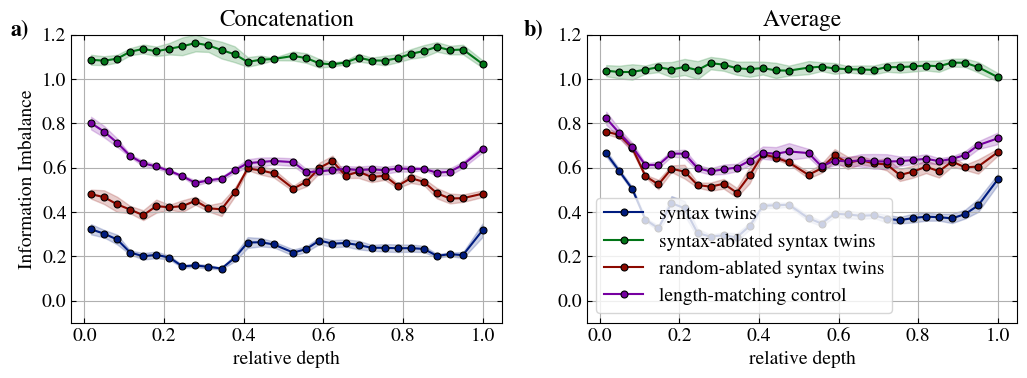

In [14]:
precision = 32
ratio_jackknife = 0.5
fig,ax = plt.subplots(1,2,figsize=(10.5,4))

match_vars = ['matching','mismatching']
for avg_id,avg_tokens in enumerate(avg_flags):

  title = ' '
  label = None
  plot_id = 0

  for match_id,match_var in enumerate(match_vars):
    for removal_method in [None,'projection']:
      _removal_method = 'projection' if removal_method == 'projection' else 'center'
      for zero_id,zero_activations in enumerate(zero_activations_list):
        for center_A_id,center_A_flag in enumerate(center_A_flags):
          for center_B_id,center_B_flag in enumerate(center_B_flags):
            if center_A_flag != center_B_flag: 
              continue
            if center_A_flag != 0 and removal_method == None:
              continue
            if center_A_flag == 0 and removal_method != None:
              continue

            if match_var == 'mismatching' and center_A_flag != 0:
              continue
            output_folder0 = makefolder(base=f'./results/',
                                        global_centering=global_centering,
                                        spaces='AB',
                                        similarity_fn='normalized_L2_distance',
                                        precision=precision,
                                        language='english',
                                        data_var=data_var,
                                        modelA=modelA,
                                        modelB=modelB,
                                        match_var=match_var,
                                        n_files=n_files,
                                        min_token_length=min_token_length,
                                        )
            II_folder = makefolder(base=output_folder0,
                                              centers=centers_var,
                                              Nbits=Nbits,
                                              n_tokens=n_tokens,
                                              avg_tokens=avg_tokens,
                                              batch_shuffle=batch_shuffle,
                                              zero_activations=zero_activations,
                                              center_A_flag=center_A_flag,
                                              center_B_flag=center_B_flag,
                                              removal_method=removal_method,
                                              )
            inf_imb = np.load(II_folder + f"II_{ratio_jackknife:.2f}.npy")
            std = np.load(II_folder + f"II_jack_std_{ratio_jackknife:.2f}.npy")

            color = colors[plot_id] 
            linestyle = '-'
            if avg_tokens:
              title = f'Average'
            else:
              title = f'Concatenation'

            label = ''
            label1 = ''
            if center_A_flag == 0:
              if match_var == 'mismatching':
                label += 'length-matching control'
                label1 += 'length-matching control'
              elif match_var == 'matching':
                label += r'$\mathbf{X}_i \rightarrow \mathbf{s}^{0}_i$'
                label1 += f'syntax twins'

            if removal_method == 'projection':    
              if center_A_flag == -1:
                label +=  r'$\mathbf{X}_i \perp \mathbf{S}_r \rightarrow \mathbf{s}^{0}_i \perp \mathbf{S}_r$'
                label1 += 'random-ablated syntax twins'
              if center_A_flag == 1:
                label += r'$\mathbf{X}_i \perp \mathbf{S}_i \rightarrow \mathbf{s}^{0}_i \perp \mathbf{S}_i$'
                label1 += 'syntax-ablated syntax twins'
              # elif removal_method == 'subtraction':
              #   if center_A_flag == -1:
              #     label +=  r'$\mathbf{X}_i - S_j \rightarrow \mathbf{s}^{0}_i - S_j \quad (j \neq i)$'
              #   if center_A_flag == 1:
              #     label += r'$\mathbf{X}_i - \mathbf{S}_i \rightarrow \mathbf{s}^{0}_i - \mathbf{S}_i$'

            for II_index in range(1):
              _label = label1
              ax[avg_id].plot(
                  layers,
                  inf_imb[II_index].diagonal(),
                  label=_label,
                  linestyle=_linestyles[II_index],
                  color=color,
                  marker='o',                # circular marker
                  markersize=5,              # tweakable size
                  markerfacecolor=color,     # fill same as line
                  markeredgecolor='black',   # cute black border
                  markeredgewidth=0.8,       # adjust border thickness
              )

              ax[avg_id].fill_between(layers,
                              inf_imb[II_index].diagonal() - std[II_index].diagonal(),
                              inf_imb[II_index].diagonal() + std[II_index].diagonal(),
                              alpha=0.2,
                              color=color,
                              )
            plot_id += 1
  ax[0].set_ylabel('Information Imbalance')
  ax[avg_id].set_xlabel('relative depth')
  ax[avg_id].set_title(title)

  ax[avg_id].grid()

  ax[avg_id].tick_params(
      top=True, bottom=True, left=True, right=True,  # enable ticks
      labeltop=False, labelbottom=True, labelleft=True, labelright=False, # enable labels if needed
      direction='in'  # ticks point inward
      )
  
  ax[avg_id].set_ylim(-.1,1.2)

   
# Inner legends in both subplots
for a in ax[1:]:
    handles, labels = [], []
    for line in a.get_lines():
        label = line.get_label()
        if label:
            handles.append(line)
            labels.append(label)
    a.legend(handles, labels, loc='best', fontsize=rcpsize, framealpha=0.8)



# Add panel labels
panel_labels = ['a)', 'b)']
for i, label in enumerate(panel_labels):
    ax[i].text(
        -0.1, 1.05,      # x, y in axis coordinates
        label,
        transform=ax[i].transAxes,  # coordinates relative to the axes
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='right'
    )

figs_folder = 'results/figs/syntax_similarity'
os.makedirs(figs_folder, exist_ok=True)
fig.savefig(f'{figs_folder}/syntax_similarity_{modelA}_{removal_method}_{center_A_flags}.pdf', bbox_inches='tight')
plt.show()

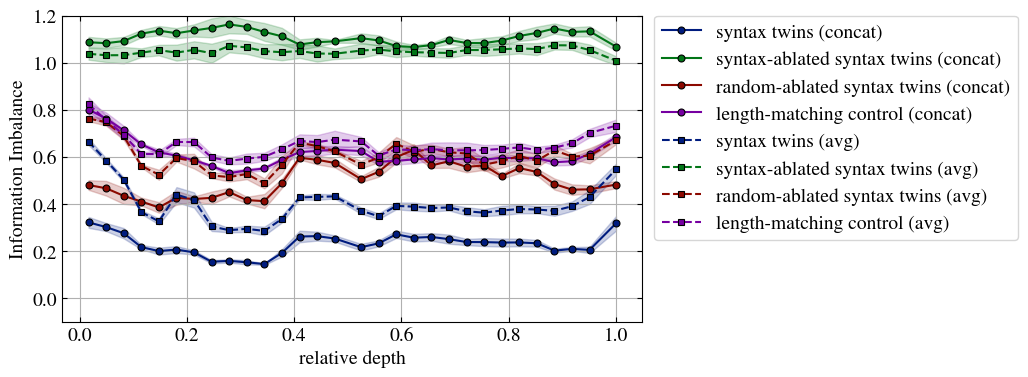

In [16]:
precision = 32
ratio_jackknife = 0.5

# Single panel instead of (1, 2)
fig, ax = plt.subplots(figsize=(10.5, 4))

match_vars = ['matching', 'mismatching']
for avg_id, avg_tokens in enumerate(avg_flags):

    title = ' '
    label = None
    plot_id = 0

    for match_id, match_var in enumerate(match_vars):
        for removal_method in [None, 'projection']:
            _removal_method = 'projection' if removal_method == 'projection' else 'center'
            for zero_id, zero_activations in enumerate(zero_activations_list):
                for center_A_id, center_A_flag in enumerate(center_A_flags):
                    for center_B_id, center_B_flag in enumerate(center_B_flags):
                        if center_A_flag != center_B_flag:
                            continue
                        if center_A_flag != 0 and removal_method is None:
                            continue
                        if center_A_flag == 0 and removal_method is not None:
                            continue

                        if match_var == 'mismatching' and center_A_flag != 0:
                            continue

                        output_folder0 = makefolder(
                            base=f'./results/',
                            global_centering=global_centering,
                            spaces='AB',
                            similarity_fn='normalized_L2_distance',
                            precision=precision,
                            language='english',
                            data_var=data_var,
                            modelA=modelA,
                            modelB=modelB,
                            match_var=match_var,
                            n_files=n_files,
                            min_token_length=min_token_length,
                        )
                        II_folder = makefolder(
                            base=output_folder0,
                            centers=centers_var,
                            Nbits=Nbits,
                            n_tokens=n_tokens,
                            avg_tokens=avg_tokens,
                            batch_shuffle=batch_shuffle,
                            zero_activations=zero_activations,
                            center_A_flag=center_A_flag,
                            center_B_flag=center_B_flag,
                            removal_method=removal_method,
                        )

                        inf_imb = np.load(II_folder + f"II_{ratio_jackknife:.2f}.npy")
                        std = np.load(II_folder + f"II_jack_std_{ratio_jackknife:.2f}.npy")

                        color = colors[plot_id]
                        linestyle = '-'
                        if avg_tokens:
                            title = 'Average'
                        else:
                            title = 'Concatenation'

                        label = ''
                        label1 = ''
                        if center_A_flag == 0:
                            if match_var == 'mismatching':
                                label += 'length-matching control'
                                label1 += 'length-matching control'
                            elif match_var == 'matching':
                                label += r'$\mathbf{X}_i \rightarrow \mathbf{s}^{0}_i$'
                                label1 += 'syntax twins'

                        if removal_method == 'projection':
                            if center_A_flag == -1:
                                label += r'$\mathbf{X}_i \perp \mathbf{S}_r \rightarrow \mathbf{s}^{0}_i \perp \mathbf{S}_r$'
                                label1 += 'random-ablated syntax twins'
                            if center_A_flag == 1:
                                label += r'$\mathbf{X}_i \perp \mathbf{S}_i \rightarrow \mathbf{s}^{0}_i \perp \mathbf{S}_i$'
                                label1 += 'syntax-ablated syntax twins'

                        for II_index in range(1):
                            # Distinguish average vs concatenation in legend
                            _label = label1
                            if avg_tokens:
                                _label += ' (avg)'
                            else:
                                _label += ' (concat)'

                            ax.plot(
                                layers,
                                inf_imb[II_index].diagonal(),
                                label=_label,
                                linestyle=_linestyles[avg_id],
                                color=color,
                                marker=markers[avg_id],
                                markersize=5,
                                markerfacecolor=color,
                                markeredgecolor='black',
                                markeredgewidth=0.8,
                            )

                            ax.fill_between(
                                layers,
                                inf_imb[II_index].diagonal() - std[II_index].diagonal(),
                                inf_imb[II_index].diagonal() + std[II_index].diagonal(),
                                alpha=0.2,
                                color=color,
                            )
                        plot_id += 1

# Axes formatting (single panel)
ax.set_ylabel('Information Imbalance')
ax.set_xlabel('relative depth')

ax.grid()

ax.tick_params(
    top=True, bottom=True, left=True, right=True,
    labeltop=False, labelbottom=True, labelleft=True, labelright=False,
    direction='in'
)

ax.set_ylim(-.1, 1.2)

# Single legend outside the plot
handles, labels = ax.get_legend_handles_labels()
# Optional: remove duplicates
by_label = dict(zip(labels, handles))
ax.legend(
    by_label.values(),
    by_label.keys(),
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    fontsize=rcpsize,
    framealpha=0.8,
)

figs_folder = 'results/figs/syntax_similarity'
os.makedirs(figs_folder, exist_ok=True)
fig.savefig(f'{figs_folder}/syntax_similarity_{modelA}_{removal_method}_length_control.pdf',
            bbox_inches='tight')
plt.show()


### Corr coef

In [ ]:
precision = 32
fig,ax = plt.subplots(1,2,figsize=(10.5,4))


for avg_id,avg_tokens in enumerate(avg_flags):
  n_tokens = min_token_length
  # avg_id += 1
  title = ' '
  label = None
  plot_id = 0

  for match_id,match_var in enumerate(match_vars):
    for removal_method in [None,'projection']:
      _removal_method = 'projection' if removal_method == 'projection' else 'center'
      for zero_id,zero_activations in enumerate(zero_activations_list):
        for center_A_id,center_A_flag in enumerate(center_A_flags):
          for center_B_id,center_B_flag in enumerate(center_B_flags):
            if center_A_flag != center_B_flag: 
              continue
            if center_A_flag != 0 and removal_method == None:
              continue
            if center_A_flag == 0 and removal_method != None:
              continue

            if match_var == 'mismatching' and center_A_flag != 0:
              continue
            output_folder0 = makefolder(base=f'./results/',
                                        global_centering=global_centering,
                                        spaces='AB',
                                        similarity_fn='normalized_L2_distance',
                                        precision=precision,
                                        language='english',
                                        data_var=data_var,
                                        modelA=modelA,
                                        modelB=modelB,
                                        match_var=match_var,
                                        n_files=n_files,
                                        min_token_length=min_token_length,
                                        )
            II_folder = makefolder(base=output_folder0,
                                              centers=centers_var,
                                              Nbits=Nbits,
                                              n_tokens=n_tokens,
                                              avg_tokens=avg_tokens,
                                              batch_shuffle=batch_shuffle,
                                              zero_activations=zero_activations,
                                              center_A_flag=center_A_flag,
                                              center_B_flag=center_B_flag,
                                              removal_method=removal_method,
                                              )
            inf_imb = np.load(II_folder + f"corr_coeff_{ratio_jackknife:.2f}.npy")
            std = np.load(II_folder + f"II_jack_std_{ratio_jackknife:.2f}.npy")

            color = colors[plot_id] 
            linestyle = '-'
            if avg_tokens:
              title = f'Average'
            else:
              title = f'Concatenation'

            label = ''
            label1 = ''
            if center_A_flag == 0:
              if match_var == 'mismatching':
                label += 'length-matching control'
              elif match_var == 'matching':
                label += r'$\mathbf{X}_i \rightarrow \mathbf{s}^{0}_i$'
                label1 += f'syntax twins'

            if removal_method == 'projection':    
              if center_A_flag == -1:
                label +=  r'$\mathbf{X}_i \perp \mathbf{S}_r \rightarrow \mathbf{s}^{0}_i \perp \mathbf{S}_r$'
                label1 += 'random-ablated syntax twins'
              if center_A_flag == 1:
                label += r'$\mathbf{X}_i \perp \mathbf{S}_i \rightarrow \mathbf{s}^{0}_i \perp \mathbf{S}_i$'
                label1 += 'syntax-ablated syntax twins'

            for II_index in range(1):
              _label = label1
              ax[avg_id].plot(
                  layers,
                  inf_imb[II_index].diagonal(),
                  label=_label,
                  linestyle=_linestyles[II_index],
                  color=color,
                  marker='o',                # circular marker
                  markersize=5,              # tweakable size
                  markerfacecolor=color,     # fill same as line
                  markeredgecolor='black',   # cute black border
                  markeredgewidth=0.8,       # adjust border thickness
              )

              ax[avg_id].fill_between(layers,
                              inf_imb[II_index].diagonal() - std[II_index].diagonal(),
                              inf_imb[II_index].diagonal() + std[II_index].diagonal(),
                              alpha=0.2,
                              color=color,
                              )
            plot_id += 1
  ax[0].set_ylabel("Chatterjee's mean ξ")
  ax[avg_id].set_xlabel('relative depth')
  ax[avg_id].set_title(title)

  ax[avg_id].grid()

  ax[avg_id].tick_params(
      top=True, bottom=True, left=True, right=True,  # enable ticks
      labeltop=False, labelbottom=True, labelleft=True, labelright=False, # enable labels if needed
      direction='in'  # ticks point inward
      )
  
  ax[avg_id].set_ylim(-.1,.5)

# box = ax[1].get_position()
# ax[1].set_position([box.x0, box.y0, box.width * 0.8, box.height])
# ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
   
# Inner legends in both subplots
for a in ax[:1]:
    handles, labels = [], []
    for line in a.get_lines():
        label = line.get_label()
        if label:
            handles.append(line)
            labels.append(label)
    a.legend(handles, labels, loc='best', fontsize=rcpsize, framealpha=0.8)



# Add panel labels
panel_labels = ['a)', 'b)']
for i, label in enumerate(panel_labels):
    ax[i].text(
        -0.1, 1.05,      # x, y in axis coordinates
        label,
        transform=ax[i].transAxes,  # coordinates relative to the axes
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='right'
    )


os.makedirs(figs_folder, exist_ok=True)
fig.savefig(f'{figs_folder}/syntax_similarity_corr_{modelA}_{removal_method}.pdf', bbox_inches='tight')
plt.show()